In [1]:
import pandas as pd

# LOADING THE DATASET

In [2]:
file_path = 'exam_questions_dataset.csv'
df = pd.read_csv(file_path)

df.head()

,question_id,subject,bloom_level,question_text,question_length,mean_score,std_dev,pass_rate,discrimination_index,difficulty_label
0,Q0001,Mathematics,Remember,What is the formula for number theory?,7,26.12,11.67,0.14,0.71,Medium
1,Q0002,Mathematics,Remember,List the properties of statistics.,5,75.82,7.21,0.88,0.28,Easy
2,Q0003,Physics,Remember,What is the SI unit of thermodynamics?,7,23.99,15.07,0.20,0.53,Medium
3,Q0004,Biology,Remember,What is osmosis?,3,53.60,10.65,0.46,0.41,Easy
4,Q0005,Physics,Create,Develop a theoretical model incorporating quan...,7,66.54,13.77,0.66,0.31,Medium


# DATA INSPECTION

In [3]:
df.shape
df.info()
df['difficulty_label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   question_id           5000 non-null   object 
 1   subject               5000 non-null   object 
 2   bloom_level           5000 non-null   object 
 3   question_text         5000 non-null   object 
 4   question_length       5000 non-null   int64  
 5   mean_score            5000 non-null   float64
 6   std_dev               5000 non-null   float64
 7   pass_rate             5000 non-null   float64
 8   discrimination_index  5000 non-null   float64
 9   difficulty_label      5000 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 390.8+ KB


difficulty_label
Medium    2525
Easy      1796
Hard       679
Name: count, dtype: int64

# Section 2: Exploratory Data Analysis (EDA)

In this section, we analyze dataset structure, class distribution, and statistical relationships between features and difficulty labels.

In [4]:
# 1. Class Distribution:
df['difficulty_label'].value_counts()

difficulty_label
Medium    2525
Easy      1796
Hard       679
Name: count, dtype: int64

In [5]:
# 2. Basic Statistics:
df.describe()

,question_length,mean_score,std_dev,pass_rate,discrimination_index
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.083200,57.416416,11.907032,0.586466,0.425962
std,1.976122,20.823677,4.761251,0.246330,0.175910
min,3.000000,20.020000,3.010000,0.100000,0.100000
25%,7.000000,40.517500,8.340000,0.390000,0.300000
50%,8.000000,57.240000,11.750000,0.600000,0.430000
75%,9.000000,74.420000,15.662500,0.800000,0.530000
max,13.000000,94.990000,21.980000,0.990000,0.800000


In [6]:
# 3. Relationship:
df.groupby('difficulty_label')[['mean_score','pass_rate']].mean()

,mean_score,pass_rate
difficulty_label,,
Easy,73.073731,0.770596
Hard,32.936318,0.285479
Medium,52.862535,0.536436


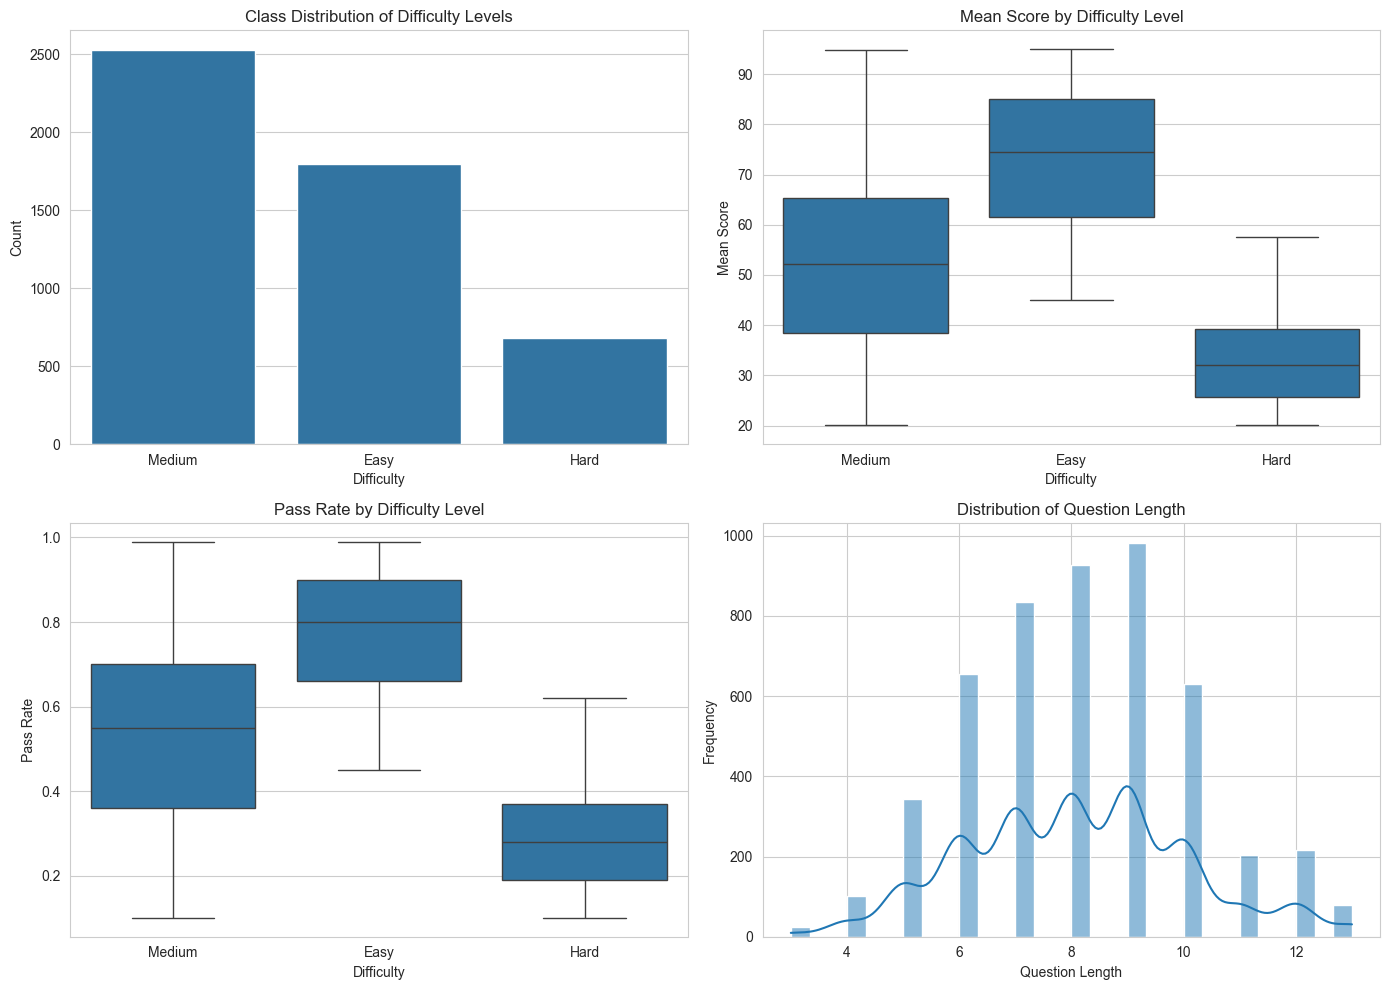

In [7]:
# 4. Graph-Plots for Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Setting style
sns.set_style("whitegrid")

plt.figure(figsize=(14,10))

# 1. Class Distribution
plt.subplot(2,2,1)
sns.countplot(x='difficulty_label', data=df)
plt.title("Class Distribution of Difficulty Levels")
plt.xlabel("Difficulty")
plt.ylabel("Count")

# 2. Mean Score vs Difficulty
plt.subplot(2,2,2)
sns.boxplot(x='difficulty_label', y='mean_score', data=df)
plt.title("Mean Score by Difficulty Level")
plt.xlabel("Difficulty")
plt.ylabel("Mean Score")

# 3. Pass Rate vs Difficulty
plt.subplot(2,2,3)
sns.boxplot(x='difficulty_label', y='pass_rate', data=df)
plt.title("Pass Rate by Difficulty Level")
plt.xlabel("Difficulty")
plt.ylabel("Pass Rate")

# 4. Question Length Distribution
plt.subplot(2,2,4)
sns.histplot(df['question_length'], bins=30, kde=True)
plt.title("Distribution of Question Length")
plt.xlabel("Question Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Section 3: Text Preprocessing & Feature Engineering

In this section, we clean textual data and extract meaningful features using TF-IDF.
We also prepare statistical features for modeling.

In [8]:
# Preprocessing the text

import re
import string
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Applying basic text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

# Applying cleaning
df['cleaned_text'] = df['question_text'].apply(clean_text)

# TF-IDF Feature Extraction

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_text = tfidf.fit_transform(df['cleaned_text'])

# Statistical Features

stat_features = ['mean_score', 'pass_rate', 'std_dev',
                 'discrimination_index', 'question_length']

X_stats = df[stat_features]

# Encode Target Variable

le = LabelEncoder()
y = le.fit_transform(df['difficulty_label'])

# Train-Test Split

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

X_stats_train, X_stats_test, _, _ = train_test_split(
    X_stats, y, test_size=0.2, random_state=42, stratify=y
)

print("Text Feature Shape:", X_text.shape)
print("Stat Feature Shape:", X_stats.shape)
print("Classes:", le.classes_)

Text Feature Shape: (5000, 251)
Stat Feature Shape: (5000, 5)
Classes: ['Easy' 'Hard' 'Medium']


# Section 4: Model Training

We train and evaluate multiple classification models to predict question difficulty.

In [9]:
# Model 1: Logistic Regression (Text-Only)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
log_reg_text = LogisticRegression(max_iter=1000)

# Train model
log_reg_text.fit(X_text_train, y_train)

# Predictions
y_pred_text = log_reg_text.predict(X_text_test)

# Evaluation
print("Text-Only Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_text))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_text))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_text))

Text-Only Logistic Regression Results
Accuracy: 0.619

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.66      0.65       359
           1       1.00      0.03      0.06       136
           2       0.60      0.75      0.67       505

    accuracy                           0.62      1000
   macro avg       0.75      0.48      0.46      1000
weighted avg       0.67      0.62      0.58      1000


Confusion Matrix:

[[237   0 122]
 [  3   4 129]
 [127   0 378]]


# Model 2: Logistic Regression (Statistical Features Only)

In this model, we use assessment performance metrics to predict difficulty.

In [10]:
# Model 2: Logistic Regression (Stats-Only)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
log_reg_stats = LogisticRegression(max_iter=1000)

# Train model
log_reg_stats.fit(X_stats_train, y_train)

# Predictions
y_pred_stats = log_reg_stats.predict(X_stats_test)

# Evaluation
print("Stats-Only Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_stats))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_stats))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_stats))

Stats-Only Logistic Regression Results
Accuracy: 0.67

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.75      0.73       359
           1       0.51      0.33      0.40       136
           2       0.66      0.71      0.68       505

    accuracy                           0.67      1000
   macro avg       0.63      0.59      0.61      1000
weighted avg       0.66      0.67      0.66      1000


Confusion Matrix:

[[268   0  91]
 [  0  45  91]
 [104  44 357]]


#Model 3: Logistic Regression (Combined Features)

In this model, we combine semantic TF-IDF features with statistical assessment features to improve prediction performance.

In [11]:
# Model 3: Combined Features

from scipy.sparse import hstack

# Combine text and stats features
X_combined = hstack([X_text, X_stats])

# Train-test split again for combined
X_comb_train, X_comb_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
log_reg_combined = LogisticRegression(max_iter=1000)
log_reg_combined.fit(X_comb_train, y_train)

# Predictions
y_pred_combined = log_reg_combined.predict(X_comb_test)

# Evaluation
print("Combined Feature Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_combined))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_combined))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_combined))

Combined Feature Logistic Regression Results
Accuracy: 0.935

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       359
           1       0.94      0.80      0.87       136
           2       0.92      0.95      0.94       505

    accuracy                           0.94      1000
   macro avg       0.94      0.90      0.92      1000
weighted avg       0.94      0.94      0.93      1000


Confusion Matrix:

[[344   0  15]
 [  0 109  27]
 [ 16   7 482]]


# Model 4: Decision Tree (Combined Features)

We train a Decision Tree classifier using hybrid features and compare its performance with Logistic Regression.

In [12]:
# Model 4: Decision Tree (Combined Features)

from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    random_state=42
)

# Train model
dt_model.fit(X_comb_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_comb_test)

# Evaluation
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.92

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       359
           1       0.88      0.82      0.85       136
           2       0.91      0.93      0.92       505

    accuracy                           0.92      1000
   macro avg       0.91      0.90      0.91      1000
weighted avg       0.92      0.92      0.92      1000


Confusion Matrix:

[[337   0  22]
 [  0 112  24]
 [ 19  15 471]]


# Model Comparison & Performance Analysis

We compared four models based on accuracy, precision, recall, and F1-score.

The hybrid Logistic Regression model achieved the highest accuracy (93.5%),
demonstrating the effectiveness of combining semantic and statistical features.

Decision Tree performed comparably (92%), indicating strong non-linear modeling capability.

# Section 5: User Interface (Prediction System)

We build an interactive interface that allows users to input a question and performance statistics to predict difficulty level.

In [14]:
import gradio as gr
import numpy as np
from scipy.sparse import hstack

# Store flagged cases
flagged_cases = []

# -------- Prediction Functions --------

def predict_text_only(question):
    cleaned = clean_text(question)
    text_vector = tfidf.transform([cleaned])
    prediction = log_reg_text.predict(text_vector)
    return le.inverse_transform(prediction)[0]

def predict_combined(question, mean_score, pass_rate, std_dev, discrimination_index, question_length):
    cleaned = clean_text(question)
    text_vector = tfidf.transform([cleaned])
    stats_array = np.array([[mean_score, pass_rate, std_dev, discrimination_index, question_length]])
    combined_features = hstack([text_vector, stats_array])
    prediction = log_reg_combined.predict(combined_features)
    return le.inverse_transform(prediction)[0]

def flag_prediction(question):
    flagged_cases.append(question)
    print("Flagged Case:", question)
    return "⚠ Prediction flagged for review."


# -------- UI Layout --------

with gr.Blocks() as demo:
    
    gr.Markdown("# AI-Based Question Difficulty Predictor")
    gr.Markdown("Choose prediction mode below.")

    with gr.Tabs():

        # 🔥 High Accuracy First
        with gr.Tab("Advanced Mode (High Accuracy)"):
            
            question = gr.Textbox(label="Enter Question Text")
            mean_score = gr.Number(label="Mean Score")
            pass_rate = gr.Number(label="Pass Rate")
            std_dev = gr.Number(label="Standard Deviation")
            discrimination_index = gr.Number(label="Discrimination Index")
            question_length = gr.Number(label="Question Length")

            output_combined = gr.Textbox(label="Predicted Difficulty")

            btn2 = gr.Button("Predict Difficulty")
            flag_btn2 = gr.Button("Flag Prediction")
            flag_output2 = gr.Textbox(label="Flag Status")

            btn2.click(
                predict_combined,
                inputs=[question, mean_score, pass_rate, std_dev, discrimination_index, question_length],
                outputs=output_combined
            )

            flag_btn2.click(
                flag_prediction,
                inputs=question,
                outputs=flag_output2
            )

        # 📝 Text Only Second
        with gr.Tab("Quick Mode (Text Only)"):
            
            question_text = gr.Textbox(label="Enter Question Text")
            output_text = gr.Textbox(label="Predicted Difficulty")

            btn1 = gr.Button("Predict Difficulty")
            flag_btn1 = gr.Button("Flag Prediction")
            flag_output1 = gr.Textbox(label="Flag Status")

            btn1.click(
                predict_text_only,
                inputs=question_text,
                outputs=output_text
            )

            flag_btn1.click(
                flag_prediction,
                inputs=question_text,
                outputs=flag_output1
            )

demo.launch()

Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


# Conclusion

This project successfully developed an AI-driven educational analytics system to predict exam question difficulty using machine learning techniques.

We implemented and compared multiple models:

- Logistic Regression (Text-Only)
- Logistic Regression (Statistical Features Only)
- Logistic Regression (Combined Features)
- Decision Tree (Combined Features)

The experimental results showed that:

- Text-only modeling achieved moderate performance (~61.9%), indicating that semantic features alone are insufficient to fully capture question difficulty.
- Statistical feature modeling improved performance (~67%), demonstrating that student performance metrics contribute meaningful predictive signals.
- The hybrid model combining TF-IDF text features and assessment statistics achieved the highest accuracy (93.5%), significantly outperforming individual feature models.
- Decision Tree achieved comparable performance (92%), validating non-linear modeling capability using Gini impurity.

These results confirm that integrating Natural Language Processing (NLP) with educational performance analytics leads to highly accurate and robust difficulty classification.

Overall, the system demonstrates how classical machine learning techniques can be effectively applied to real-world educational assessment challenges.

# Future Scope

While this milestone focused on predictive modeling, the system can be extended into an agent-based AI assessment assistant in Milestone 2.

Future enhancements include:

- Developing an agentic AI system that autonomously evaluates question quality.
- Integrating retrieval-based mechanisms to access pedagogical best practices.
- Automatically generating structured feedback for improving weak or ambiguous questions.
- Implementing reasoning workflows to assess alignment with Bloom’s taxonomy.
- Deploying the system as a scalable web application for institutional use.

By evolving from predictive analytics to autonomous reasoning, the system can transform from a difficulty classifier into an intelligent assessment design assistant, supporting educators in creating higher-quality evaluation frameworks.

In [15]:
import joblib

# Save models
joblib.dump(log_reg_text, "log_reg_text.pkl")
joblib.dump(log_reg_combined, "log_reg_combined.pkl")

# Save vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

print("Models saved successfully.")

Models saved successfully.
